### Translation

In [1]:
import numpy as np
import cv2 as cv
import imutils
import matplotlib.pyplot as plt

In [2]:
img = cv.imread("colors.jpg")
cv.imshow("Image", img)
if cv.waitKey(0):
    cv.destroyAllWindows()   

In [3]:
M = np.float32([
    [1,0,25],
    [0,1,50]
])
shifted = cv.warpAffine(img, M, (img.shape[1], img.shape[0]))
cv.imshow("Shifted Down and Right", shifted)
if cv.waitKey(0):
    cv.destroyAllWindows()   

In [4]:
M = np.float32([
    [1,0,-25],
    [0,1,-50]
])
shifted = cv.warpAffine(img, M, (img.shape[1], img.shape[0]))
cv.imshow("Shifted Up and Left", shifted)
if cv.waitKey(0):
    cv.destroyAllWindows()   

In [5]:
def translate_image(image, x, y):
    M = np.float32([
        [1,0,x],
        [0,1,y]
    ])
    shifted = cv.warpAffine(img, M, (img.shape[1], img.shape[0]))
    return shifted

In [6]:
shifted = translate_image(img, -50, 90)
cv.imshow("Translated image", shifted)
if cv.waitKey(0):
    cv.destroyAllWindows() 

### Rotation

In [7]:
(h,w) = img.shape[:2]
center = (w//2, h//2)
M = cv.getRotationMatrix2D(center, 45, 1.0)
rotated = cv.warpAffine(img, M, (w,h))
cv.imshow("Rotated image", rotated)
if cv.waitKey(0):
    cv.destroyAllWindows() 

In [8]:
def rotation_image(image, angle, scale):
    (h,w) = img.shape[:2]
    center = (w//2, h//2)
    M = cv.getRotationMatrix2D(center, angle, scale)
    rotated = cv.warpAffine(img, M, (w,h))
    return rotated

In [9]:
rotated = rotation_image(img, 45, 1.0)
cv.imshow("Rotated image", rotated)
if cv.waitKey(0):
    cv.destroyAllWindows() 

### Resizing

In [10]:
h = img.shape[0]
w = img.shape[1]
r = 50.0 / h
dim = (int(w*r), 50)
resized = cv.resize(img, dim, interpolation=cv.INTER_AREA)
cv.imshow("Resized image", resized)
if cv.waitKey(0):
    cv.destroyAllWindows() 

In [11]:
resized = imutils.resize(img, width=100)
cv.imshow("Resized image with imutils", resized)
if cv.waitKey(0):
    cv.destroyAllWindows() 

### Flipping

In [12]:
flipped = cv.flip(img, 1)
cv.imshow("flipped horizontally", flipped)
if cv.waitKey(0):
    cv.destroyAllWindows() 

In [13]:
flipped = cv.flip(img, 0)
cv.imshow("flipped vertically", flipped)
if cv.waitKey(0):
    cv.destroyAllWindows() 

In [14]:
flipped = cv.flip(img, -1)
cv.imshow("flipped horizontally and vertically", flipped)
if cv.waitKey(0):
    cv.destroyAllWindows() 

### Cropping

In [15]:
cropped = img[30:120, 240:335]
cv.imshow("cropped image", cropped)
if cv.waitKey(0):
    cv.destroyAllWindows() 

### Arithmatics

In [16]:
M = np.ones(img.shape, dtype="uint8")*100
subtracted = cv.subtract(img, M)
cv.imshow("Subtracted image", subtracted)
if cv.waitKey(0):
    cv.destroyAllWindows() 

In [17]:
rectangle = np.zeros((300,300), dtype="uint8")
cv.rectangle(rectangle, (25,25), (275,275), 255, -1)
cv.imshow("Rectangle", rectangle)       

circle = np.zeros((300,300), dtype="uint8")
cv.circle(circle, (150, 150), 150, 255, -1)
cv.imshow("Circle", circle)

if cv.waitKey(0):
    cv.destroyAllWindows() 

### Bitwise Operations

In [18]:
bitwiseAnd = cv.bitwise_and(rectangle, circle)
cv.imshow("And", bitwiseAnd)
if cv.waitKey(0):
    cv.destroyAllWindows() 

In [19]:
bitwiseOr = cv.bitwise_or(rectangle, circle)
cv.imshow("Or", bitwiseOr)
if cv.waitKey(0):
    cv.destroyAllWindows() 

In [20]:
bitwiseXor = cv.bitwise_xor(rectangle, circle)
cv.imshow("Xor", bitwiseXor)
if cv.waitKey(0):
    cv.destroyAllWindows() 

In [21]:
bitwiseNot = cv.bitwise_not(rectangle, circle)
cv.imshow("Not", bitwiseNot)
if cv.waitKey(0):
    cv.destroyAllWindows() 

### Masking

In [22]:
mask = np.zeros(img.shape[:2], dtype="uint8")
(Cx, Cy) = img.shape[1]//2, img.shape[0]//2
cv.rectangle(mask, [Cx -75, Cy-75], [Cx+75, Cy+75], 255, -1)
cv.imshow("Mask", mask)
if cv.waitKey(0):
    cv.destroyAllWindows() 

In [23]:
masked_image = cv.bitwise_and(img, img, mask=mask)
cv.imshow("Masked Image", masked_image)
if cv.waitKey(0):
    cv.destroyAllWindows() 

### Color Spaces

In [24]:
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
cv.imshow("Gray Image", gray)

hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)
cv.imshow("HSV Image", hsv)

lab = cv.cvtColor(img, cv.COLOR_BGR2LAB)
cv.imshow("Lab Image", lab)

if cv.waitKey(0):
    cv.destroyAllWindows() 

### Histograms

In [25]:
image = cv.imread("grayscale_image.jpg")
image = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
cv.imshow("Grayscale Image", image)
if cv.waitKey(0):
    cv.destroyAllWindows() 

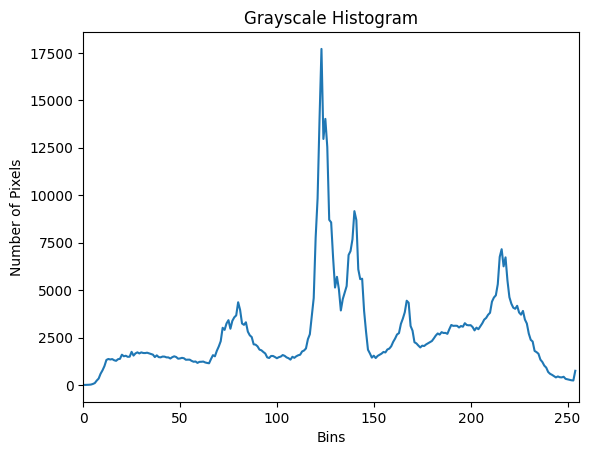

In [26]:
hist = cv.calcHist([image], [0], None, [255], [0,256])
plt.figure()
plt.title("Grayscale Histogram")
plt.xlabel("Bins")
plt.ylabel("Number of Pixels")
plt.plot(hist)
plt.xlim([0,256])
plt.show()

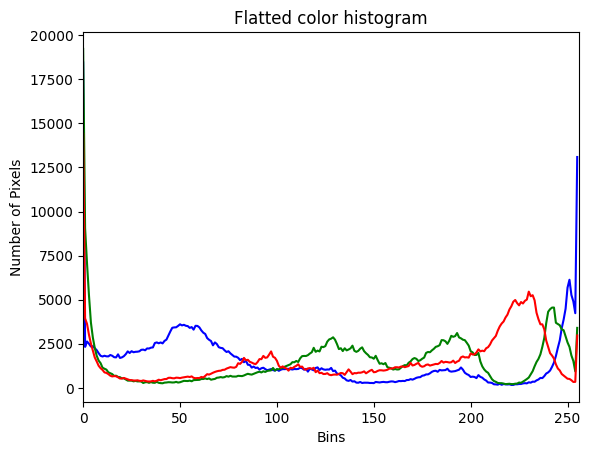

In [27]:
colors_image = cv.imread("colors.jpg")
chans = cv.split(colors_image)
colors = ("b", "g", "r")
plt.figure()
plt.title("Flatted color histogram")
plt.xlabel("Bins")
plt.ylabel("Number of Pixels")

for(chan, color) in zip(chans, colors):
    hist = cv.calcHist([chan], [0], None, [256], [0,256])
    plt.plot(hist, color=color)
    plt.xlim([0,256])
plt.show()

### Smoothing And Blurring

In [28]:
image = cv.imread("colors.jpg")
blurred = np.hstack(
    [
        cv.blur(image, (3,3)),
        cv.blur(image, (5,5)),
        cv.blur(image, (7,7))
    ]
)
cv.imshow("Blurred Image", blurred)
if cv.waitKey(0):
    cv.destroyAllWindows() 

In [29]:
GaussianBlur = np.hstack(
    [
        cv.GaussianBlur(image, (3,3), 0),
        cv.GaussianBlur(image, (5,5), 0),
        cv.GaussianBlur(image, (7,7), 0),
    ]
)
cv.imshow("GaussianBlurred Image", GaussianBlur)
if cv.waitKey(0):
    cv.destroyAllWindows() 

In [30]:
medianBlur = np.hstack(
    [
        cv.medianBlur(image, 3),
        cv.medianBlur(image, 5),
        cv.medianBlur(image, 7),
    ]
)
cv.imshow("MedianBlurred Image", medianBlur)
if cv.waitKey(0):
    cv.destroyAllWindows() 